In [1]:
import matplotlib.pyplot as plt
# 设置中文字体支持
import matplotlib.font_manager as fm
# 备选中文字体列表
chinese_fonts = [
    "SimHei",           # Windows
    "Heiti TC",         # macOS
    "WenQuanYi Micro Hei",  # Linux
    "Microsoft YaHei",  # 微软雅黑
    "Arial Unicode MS", # 备选
]

# 获取系统可用字体
available_fonts = {f.name for f in fm.fontManager.ttflist}

# 查找第一个可用的中文字体
for font in chinese_fonts:
    if font in available_fonts:
        plt.rcParams["font.family"] = font
        break

plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

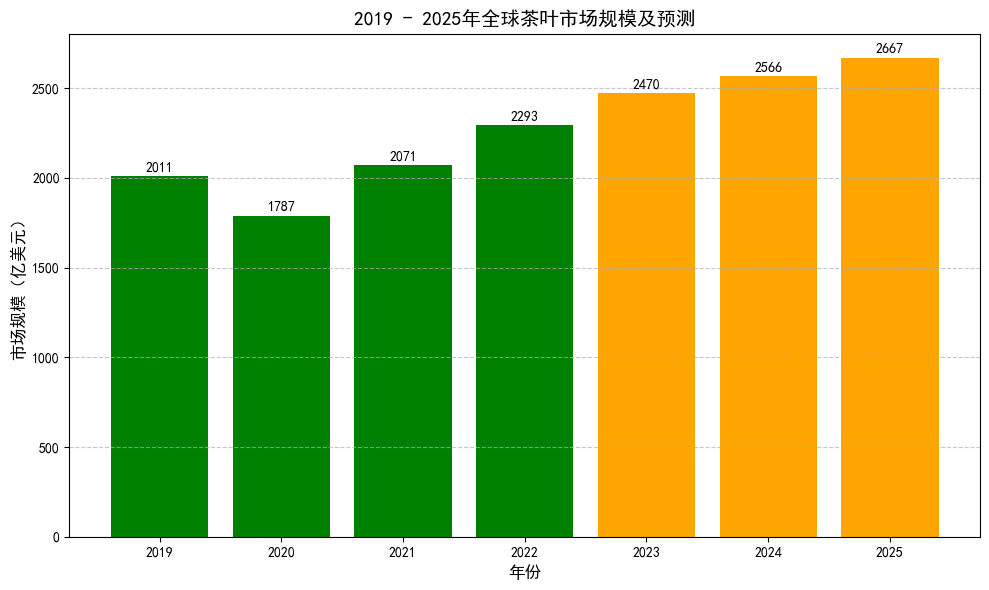

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# 年份
years = np.array([2019, 2020, 2021, 2022, 2023, 2024, 2025])
# 市场规模（亿美元），2023 - 2025 为预测值（E）
market_size = np.array([2011, 1787, 2071, 2293, 2470, 2566, 2667])
# 为预测年份（2023 - 2025）标记特殊颜色
colors = ['green'] * 4 + ['orange'] * 3

plt.figure(figsize=(10, 6))  # 设置图表大小
bars = plt.bar(years, market_size, color=colors)

# 在每个柱子上方添加数值标注
for bar, value in zip(bars, market_size):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 15,
             f'{value}', ha='center', va='bottom', fontsize=10)

# 添加标题和坐标轴标签
plt.title('2019 - 2025年全球茶叶市场规模及预测', fontsize=14)
plt.xlabel('年份', fontsize=12)
plt.ylabel('市场规模（亿美元）', fontsize=12)

# 设置x轴刻度为年份
plt.xticks(years)

# 添加网格线
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 显示图表
plt.tight_layout()  # 调整布局
plt.show()    

C:\Users\tomatoyuan\AppData\Local\Temp\ipykernel_33128\2474131027.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=countries, y=market_size, palette=['orange'] + ['green']*(len(countries)-1))


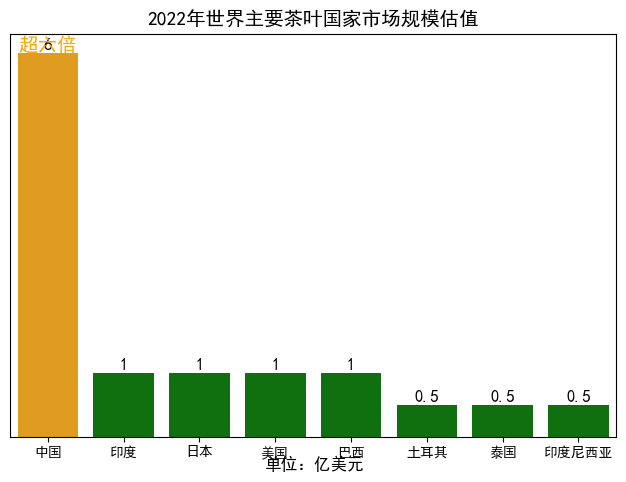

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

countries = ["中国", "印度", "日本", "美国", "巴西", "土耳其", "泰国", "印度尼西亚"]
market_size = [6, 1, 1, 1, 1, 0.5, 0.5, 0.5]

x = np.arange(len(countries))
sns.barplot(x=countries, y=market_size, palette=['orange'] + ['green']*(len(countries)-1))

# 添加数值标注
for i, v in enumerate(market_size):
    plt.text(i, v + 0.05, f'{v}', ha='center', fontsize=12)

plt.text(0, market_size[0], "超六倍", ha='center', va='bottom', fontsize=14, color='orange')
plt.title("2022年世界主要茶叶国家市场规模估值", fontsize=14, fontweight='bold')
plt.figtext(0.5, 0.01, "单位：亿美元", ha='center', fontsize=12)
plt.yticks([])
plt.tight_layout()  # 调整布局避免文字被遮挡
plt.show()    

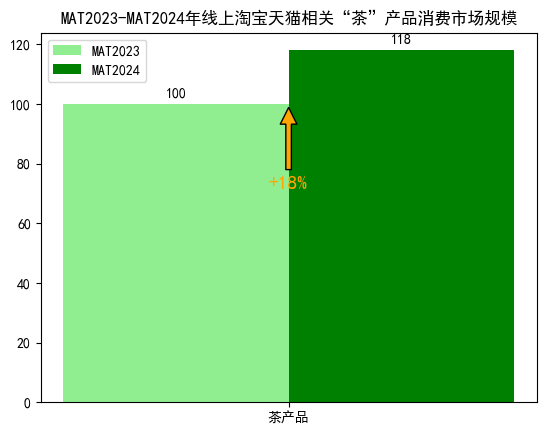

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# 数据
categories = ['茶产品']
mat2023 = [100]  # 假设的 MAT2023 数据，可替换为真实值
mat2024 = [118]  # 根据 +18% 假设的 MAT2024 数据，可替换为真实值 
growth_rate = 18  # 增长率

x = np.arange(len(categories))  # 柱状图 x 轴位置
width = 0.35  # 柱状图宽度

fig, ax = plt.subplots()
rects1 = ax.bar(x - width/2, mat2023, width, label='MAT2023', color='lightgreen')
rects2 = ax.bar(x + width/2, mat2024, width, label='MAT2024', color='green')

# 添加增长率箭头和文本
arrow_x = x[0]
arrow_y = max(mat2023 + mat2024) * 0.6  # 箭头位置，可调整
ax.annotate(f'+{growth_rate}%', xy=(arrow_x, mat2023[0]), xytext=(arrow_x, arrow_y),
            arrowprops=dict(facecolor='orange', shrink=0.05),
            ha='center', va='bottom', fontsize=14, color='orange')

# 添加数值标注函数
def add_labels(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

# 为两个柱子添加数值标注
add_labels(rects1)
add_labels(rects2)

# 设置坐标轴标签等
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()

plt.title('MAT2023-MAT2024年线上淘宝天猫相关“茶”产品消费市场规模')
plt.show()

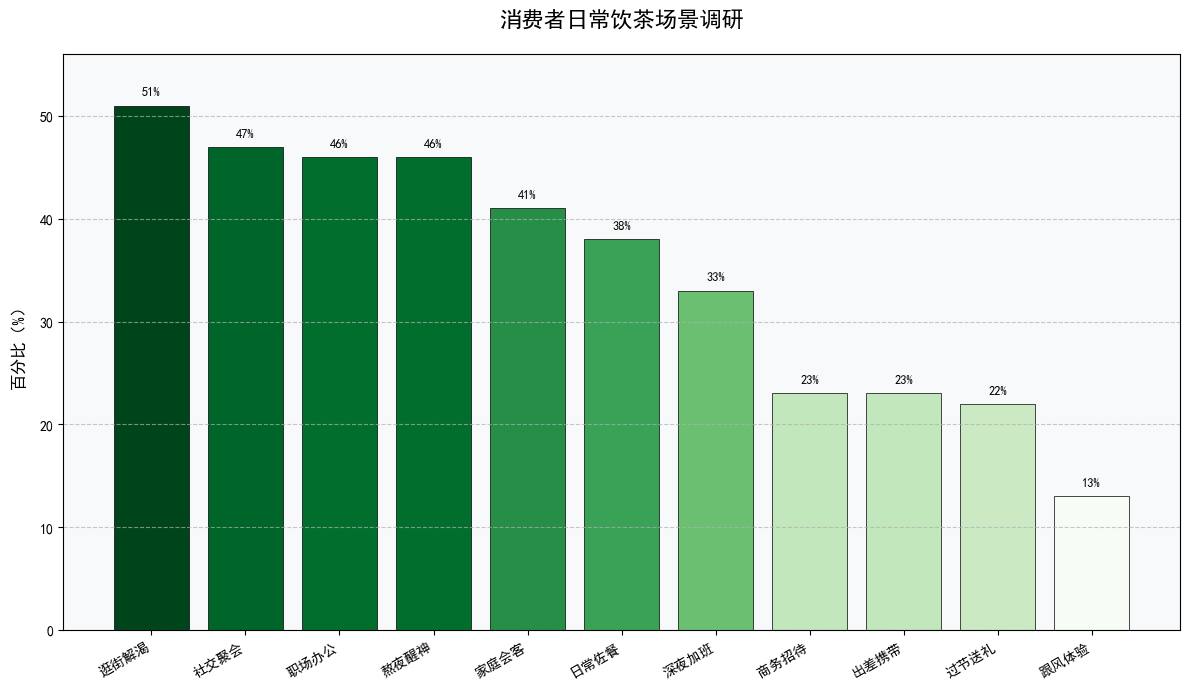

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# 场景名称
scenarios = [
    "逛街解渴", "社交聚会", "职场办公", "熬夜醒神", 
    "家庭会客", "日常佐餐", "深夜加班", "商务招待", 
    "出差携带", "过节送礼", "跟风体验"
]

# 对应场景的比例数据
percentages = [51, 47, 46, 46, 41, 38, 33, 23, 23, 22, 13]

# 数据排序（可选）
sort_data = True
if sort_data:
    # 按百分比从高到低排序
    sorted_data = sorted(zip(percentages, scenarios), reverse=True)
    percentages, scenarios = zip(*sorted_data)

# 创建画布和子图，设置图表尺寸
fig, ax = plt.subplots(figsize=(12, 7))

# 使用渐变色填充条形图
cmap = plt.cm.Greens
norm = plt.Normalize(min(percentages), max(percentages))
colors = cmap(norm(percentages))

# 创建条形图
bars = ax.bar(scenarios, percentages, color=colors, edgecolor='black', linewidth=0.5)

# 添加标题和标签
ax.set_title("消费者日常饮茶场景调研", fontsize=16, pad=20)
ax.set_ylabel("百分比（%）", fontsize=12, labelpad=10)

# 设置 x 轴标签旋转角度和字体大小
plt.xticks(rotation=30, ha='right', fontsize=10)

# 添加网格线
ax.yaxis.grid(True, linestyle='--', alpha=0.7)

# 在每个条形上方添加数值标签
for bar, percentage in zip(bars, percentages):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2.,
        height + 0.8,  # 微调标签位置
        f'{percentage}%',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

# 设置 y 轴范围
plt.ylim(0, max(percentages) + 5)

# 添加背景色
ax.set_facecolor('#f8f9fa')

# 优化布局
plt.tight_layout()

# 显示图表
plt.show()